##Principal Component Analysis

##Author -Yashas Samaga




### libraries

In [1]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt

### Import Data Set

In [2]:
df = pd.read_csv("Wine.csv")
print("Data")
print(df)

x= df.iloc[:,:-1].values
y=df.iloc[:,-1].values

print("Features")

print(x)

print("Dependent Variable")

print(y)

Data
     Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0      14.23        1.71  2.43          15.6        127           2.80   
1      13.20        1.78  2.14          11.2        100           2.65   
2      13.16        2.36  2.67          18.6        101           2.80   
3      14.37        1.95  2.50          16.8        113           3.85   
4      13.24        2.59  2.87          21.0        118           2.80   
..       ...         ...   ...           ...        ...            ...   
173    13.71        5.65  2.45          20.5         95           1.68   
174    13.40        3.91  2.48          23.0        102           1.80   
175    13.27        4.28  2.26          20.0        120           1.59   
176    13.17        2.59  2.37          20.0        120           1.65   
177    14.13        4.10  2.74          24.5         96           2.05   

     Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0          3.06          

### Splitting the dataset into the Training set and Test set


In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=1)


### Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [5]:
x_train

array([[-1.23907779, -0.76709153,  0.23605013, ...,  0.39472053,
         0.08573352, -0.97342953],
       [-0.34016831, -0.5095809 , -0.55347944, ...,  0.87437937,
         0.77219361, -0.09029683],
       [-1.13919896, -0.87009578,  0.5231518 , ..., -0.12854366,
         0.84224056, -1.1908675 ],
       ...,
       [ 0.62116544, -0.63833622, -0.4099286 , ...,  0.08948309,
         0.26785558, -0.89983514],
       [-0.07798638,  0.34878788,  1.24090595, ..., -0.82622924,
        -0.39058573, -0.47164959],
       [ 0.07183187, -0.6469199 ,  0.70259033, ...,  0.69995797,
        -0.11039794,  1.21767621]])

### Applying PCA to reduce dimensions of training Set

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_train=pca.fit_transform(x_train)
x_test=pca.transform(x_test)

In [7]:
x_train

array([[-1.45106785, -1.85914043],
       [ 1.16342695, -1.41297331],
       [-0.34393861, -1.93870926],
       [ 2.07390734,  1.34699026],
       [ 2.23752594,  1.19567755],
       [-0.7828473 , -3.0422216 ],
       [-3.43658215,  0.77277023],
       [ 2.62885478,  1.98362772],
       [ 2.80963595,  1.6148153 ],
       [ 2.20232818,  0.08703376],
       [ 1.31986145, -0.49139954],
       [ 1.97911028,  1.83895989],
       [ 3.61043285,  2.64964226],
       [ 3.2259453 ,  1.87544577],
       [-1.47273339, -1.2067983 ],
       [-2.41322827,  2.10176234],
       [-2.72253833,  1.49073541],
       [ 2.21048357,  0.73591746],
       [-1.22981038, -2.13708256],
       [ 2.59662572,  0.57316588],
       [ 2.28538266,  0.79400766],
       [ 1.14029108, -1.4207965 ],
       [-2.97735484,  0.31157243],
       [ 2.34420508, -1.84502004],
       [-0.29998197, -0.63284081],
       [ 1.97134055,  1.75622297],
       [-2.87846692,  1.45084492],
       [-0.40424353, -2.67636222],
       [-3.07957409,

### Training Logistic Regression model on the training set

In [8]:
from sklearn.linear_model import LogisticRegression
classifier= LogisticRegression(random_state=0)
classifier.fit(x_train,y_train)


LogisticRegression(random_state=0)

### confusiuon matrix and accurecy

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
print('\nconfusion_matrix\n')

y_pred=classifier.predict(x_test)
print(confusion_matrix(y_test, y_pred))

print('\naccuracy_score\n')
print(accuracy_score(y_test, y_pred))


confusion_matrix

[[14  0  0]
 [ 1 12  0]
 [ 0  0  9]]

accuracy_score

0.9722222222222222


### visualizing trainin set

/tmp/ipykernel_28344/1883257315.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green','blue'))(i), label = j)


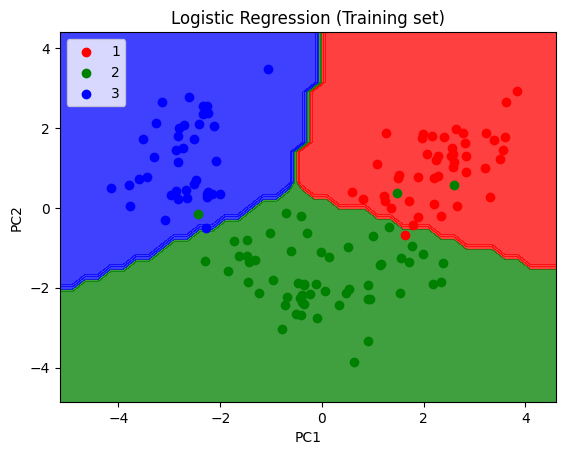

In [10]:
from matplotlib.colors import ListedColormap

X_set, y_set = x_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.25))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green','blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green','blue'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()


### visualizing Test set

/tmp/ipykernel_28344/2466460360.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green','blue'))(i), label = j)


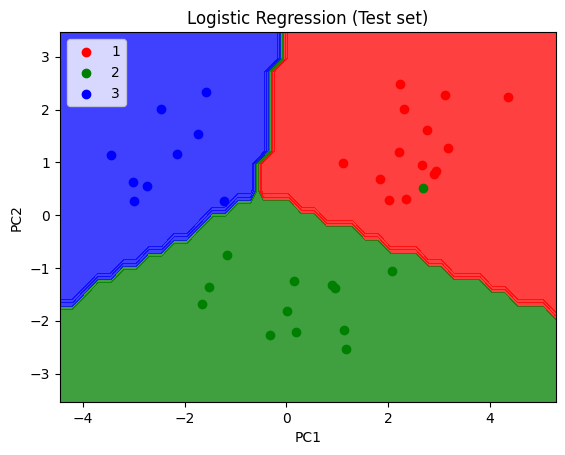

In [11]:
from matplotlib.colors import ListedColormap

X_set, y_set = x_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.25))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green','blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green','blue'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()
